# 07 — Shipping Mode Analysis
Compare order volume, revenue, profit, and average days-to-ship across all shipping modes.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("07 — Shipping Mode Analysis")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 17:01:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
df = spark.sql('''
    SELECT
        o.ship_mode,
        COUNT(DISTINCT o.order_id)  AS total_orders,
        ROUND(SUM(oi.sales),  2)    AS total_sales,
        ROUND(SUM(oi.profit), 2)    AS total_profit,
        ROUND(AVG(DATEDIFF(
            TO_DATE(o.ship_date,  "M/d/yyyy"),
            TO_DATE(o.order_date, "M/d/yyyy")
        )), 1)                      AS avg_days_to_ship
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY o.ship_mode ORDER BY total_sales DESC
''').toPandas()
print(df)

        ship_mode  total_orders  total_sales  total_profit  avg_days_to_ship
0  Standard Class          2994   1358215.74     164088.79               5.0
1    Second Class           964    459193.57      57446.64               3.2
2     First Class           787    351428.42      48969.84               2.2
3        Same Day           264    128363.12      15891.76               0.0


## Visualisation

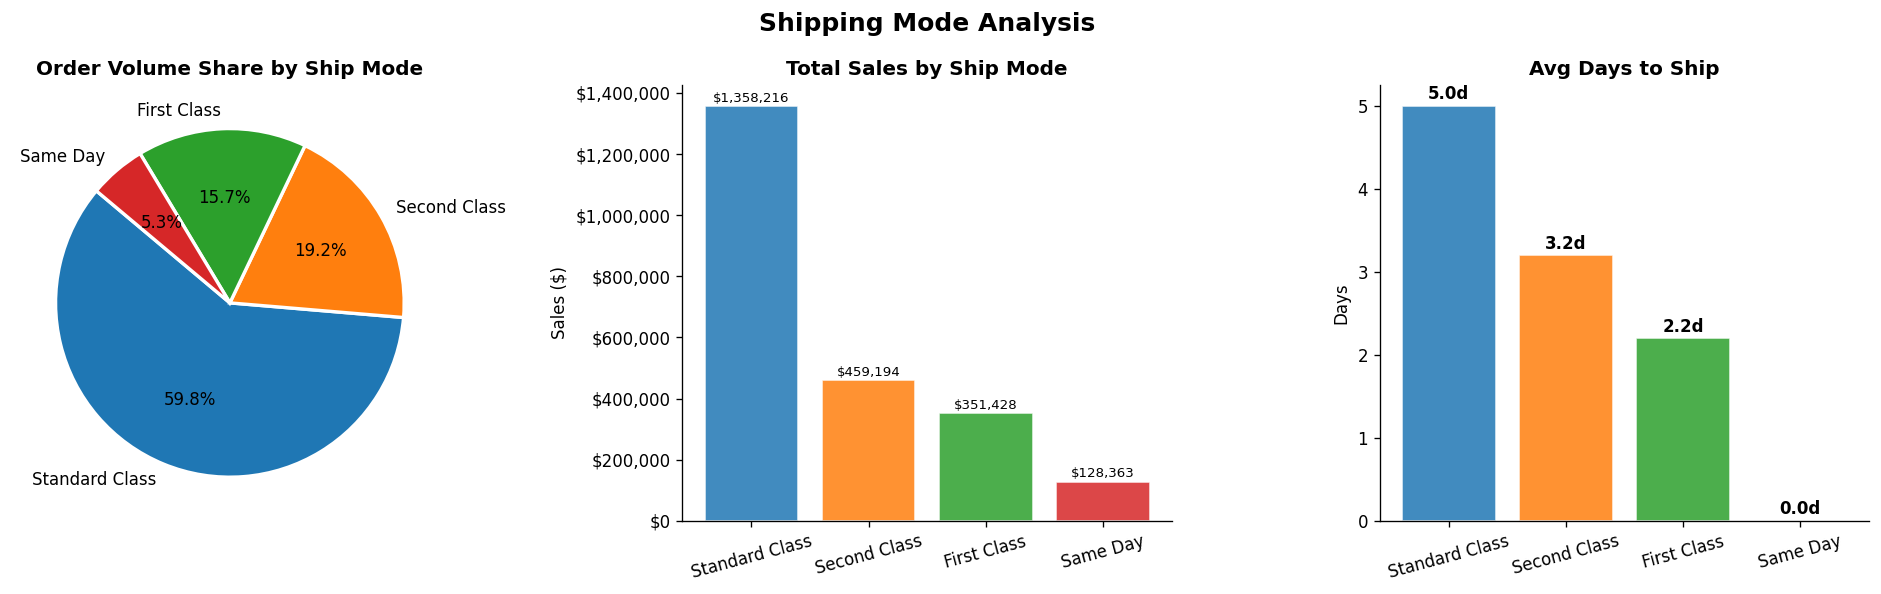

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/07_shipping_mode.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]

axes[0].pie(df["total_orders"], labels=df["ship_mode"], autopct="%1.1f%%",
            colors=colors, startangle=140, wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title("Order Volume Share by Ship Mode", fontweight="bold")

axes[1].bar(df["ship_mode"], df["total_sales"], color=colors, alpha=0.85, edgecolor="white")
for i,v in enumerate(df["total_sales"]):
    axes[1].text(i, v+max(df["total_sales"])*0.01, f"${v:,.0f}", ha="center", fontsize=8)
axes[1].set_title("Total Sales by Ship Mode", fontweight="bold"); axes[1].set_ylabel("Sales ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[1].tick_params(axis="x", rotation=15)

bars = axes[2].bar(df["ship_mode"], df["avg_days_to_ship"], color=colors, alpha=0.85, edgecolor="white")
for bar,v in zip(bars, df["avg_days_to_ship"]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.08, f"{v:.1f}d", ha="center", fontsize=10, fontweight="bold")
axes[2].set_title("Avg Days to Ship", fontweight="bold"); axes[2].set_ylabel("Days")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Shipping Mode Analysis", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/07_shipping_mode.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/07_shipping_mode.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
